### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data/coupons.csv')

In [3]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [4]:
#Checking out the info to see all columns and dtypes in list view.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [5]:
#Checking the head of dataset to view all columns and rows to examine data.
pd.set_option('display.max_columns', None)
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,education,occupation,income,car,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,0


In [6]:
#renaming columns to fix typo (passanger) and create uniformity for easy legibility. 
#Making capitalization uniform as well as separating words with underscores.
data.rename(columns={
    'passanger' : 'passenger',
    'maritalStatus' : 'marital_status',
    'Bar' : 'bar',
    'CoffeeHouse' : 'coffee_house',
    'CarryAway' : 'carry_away',
    'RestaurantLessThan20' : 'restaurant_less_than_20',
    'Restaurant20To50' : 'restaurant_20_to_50',
    'toCoupon_GEQ5min' : 'to_coupon_GEQ_5min',
    'toCoupon_GEQ15min' : 'to_coupon_GEQ_15min',
    'toCoupon_GEQ25min' : 'to_coupon_GEQ_25min'}, inplace=True)

In [7]:
#confirming renaming was successful.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   destination              12684 non-null  object
 1   passenger                12684 non-null  object
 2   weather                  12684 non-null  object
 3   temperature              12684 non-null  int64 
 4   time                     12684 non-null  object
 5   coupon                   12684 non-null  object
 6   expiration               12684 non-null  object
 7   gender                   12684 non-null  object
 8   age                      12684 non-null  object
 9   marital_status           12684 non-null  object
 10  has_children             12684 non-null  int64 
 11  education                12684 non-null  object
 12  occupation               12684 non-null  object
 13  income                   12684 non-null  object
 14  car                      108 non-null 

In [8]:
#Viewing a more randomized sample of 10 rows to explore potential patterns or find unique data
data.sample(10)

,destination,passenger,weather,temperature,time,coupon,expiration,gender,age,marital_status,has_children,education,occupation,income,car,bar,coffee_house,carry_away,restaurant_less_than_20,restaurant_20_to_50,to_coupon_GEQ_5min,to_coupon_GEQ_15min,to_coupon_GEQ_25min,direction_same,direction_opp,Y
3660,Home,Alone,Sunny,55,6PM,Restaurant(20-50),1d,Female,31,Married partner,1,Bachelors degree,Sales & Related,$12500 - $24999,NaN,less1,1~3,1~3,1~3,less1,1,1,0,0,1,1
6969,Home,Partner,Sunny,80,6PM,Coffee House,1d,Female,31,Married partner,0,Some college - no degree,Computer & Mathematical,$100000 or More,NaN,less1,less1,gt8,4~8,less1,1,0,0,1,0,1
8984,No Urgent Place,Kid(s),Sunny,80,10AM,Coffee House,1d,Female,46,Married partner,1,High School Graduate,Transportation & Material Moving,$37500 - $49999,NaN,less1,less1,1~3,1~3,never,1,0,0,0,1,1
1804,Work,Alone,Sunny,55,7AM,Bar,1d,Male,36,Unmarried partner,1,Some college - no degree,Unemployed,$87500 - $99999,NaN,1~3,less1,4~8,1~3,less1,1,1,1,0,1,1
2012,No Urgent Place,Friend(s),Sunny,80,6PM,Restaurant(<20),2h,Female,50plus,Married partner,1,Associates degree,Legal,$100000 or More,NaN,less1,never,gt8,4~8,1~3,1,1,0,0,1,1
12458,No Urgent Place,Friend(s),Sunny,80,6PM,Restaurant(<20),2h,Male,41,Divorced,1,High School Graduate,Sales & Related,$12500 - $24999,NaN,never,less1,less1,1~3,4~8,1,0,0,0,1,1
9337,No Urgent Place,Friend(s),Sunny,80,2PM,Restaurant(20-50),1d,Female,50plus,Single,1,Associates degree,Retired,Less than $12500,NaN,never,never,less1,never,never,1,1,0,0,1,0
1156,No Urgent Place,Partner,Sunny,80,6PM,Bar,1d,Female,31,Married partner,0,Some college - no degree,Computer & Mathematical,$100000 or More,NaN,less1,less1,gt8,4~8,less1,1,1,0,0,1,1
8405,Work,Alone,Snowy,30,7AM,Restaurant(<20),2h,Female,50plus,Single,0,Bachelors degree,Installation Maintenance & Repair,$25000 - $37499,NaN,never,4~8,4~8,gt8,less1,1,1,1,0,1,1
8707,Home,Alone,Snowy,30,6PM,Coffee House,1d,Male,31,Married partner,0,Graduate degree (Masters or Doctorate),Business & Financial,$75000 - $87499,NaN,1~3,4~8,less1,4~8,less1,1,1,0,0,1,1


2. Investigate the dataset for missing or problematic data.

In [9]:
#starting with the 'car' column, since the majority of values in this column are null, I will drop altogether.
#Before I do, I want to explore the options that were entered out of curiosity. Since there are only 108 of 12684 
#that have values, I will assume they are not necessary.
data['car'].unique()

array([nan, 'Scooter and motorcycle', 'crossover', 'Mazda5',
       'do not drive', 'Car that is too old to install Onstar :D'],
      dtype=object)

In [10]:
if 'car' in data.columns:
    data.drop(columns=['car'], inplace=True)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   destination              12684 non-null  object
 1   passenger                12684 non-null  object
 2   weather                  12684 non-null  object
 3   temperature              12684 non-null  int64 
 4   time                     12684 non-null  object
 5   coupon                   12684 non-null  object
 6   expiration               12684 non-null  object
 7   gender                   12684 non-null  object
 8   age                      12684 non-null  object
 9   marital_status           12684 non-null  object
 10  has_children             12684 non-null  int64 
 11  education                12684 non-null  object
 12  occupation               12684 non-null  object
 13  income                   12684 non-null  object
 14  bar                      12577 non-nul

Continuing to explore unique values from different columns to get a feel for dataset.

In [12]:
data['bar'].unique()

array(['never', 'less1', '1~3', 'gt8', nan, '4~8'], dtype=object)

In [13]:
data['bar'].value_counts(dropna=False)

bar
never    5197
less1    3482
1~3      2473
4~8      1076
gt8       349
NaN       107
Name: count, dtype: int64

In [14]:
data['coffee_house'].unique()

array(['never', 'less1', '4~8', '1~3', 'gt8', nan], dtype=object)

In [15]:
data['coffee_house'].value_counts(dropna=False)

coffee_house
less1    3385
1~3      3225
never    2962
4~8      1784
gt8      1111
NaN       217
Name: count, dtype: int64

In [16]:
data['carry_away'].unique()

array([nan, '4~8', '1~3', 'gt8', 'less1', 'never'], dtype=object)

In [17]:
data['carry_away'].value_counts(dropna=False)

carry_away
1~3      4672
4~8      4258
less1    1856
gt8      1594
never     153
NaN       151
Name: count, dtype: int64

In [18]:
data['restaurant_less_than_20'].unique()

array(['4~8', '1~3', 'less1', 'gt8', nan, 'never'], dtype=object)

In [19]:
data['restaurant_less_than_20'].value_counts(dropna=False)

restaurant_less_than_20
1~3      5376
4~8      3580
less1    2093
gt8      1285
never     220
NaN       130
Name: count, dtype: int64

In [20]:
data['restaurant_20_to_50'].unique()

array(['1~3', 'less1', 'never', 'gt8', '4~8', nan], dtype=object)

In [21]:
data['restaurant_20_to_50'].value_counts(dropna=False)

restaurant_20_to_50
less1    6077
1~3      3290
never    2136
4~8       728
gt8       264
NaN       189
Name: count, dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

Dropped 'car' column above.
After exploring NaN values in frequency of visits to restaurants, coffee houses, takeout food, and
bars, since in all cateogries NaN values are small in comparison, I will choose to replace NaN values with "never", since there is a likelihood that the respondent did not respond here since it did not apply to them. Additionally, since the NaN values are so small, any impact to data will be negligible. 

In [22]:
#setting aside columns with NaN values
how_often_columns=['bar', 'coffee_house', 'carry_away','restaurant_less_than_20','restaurant_20_to_50']

In [23]:
#Replacing NaN values with 'never'
data[how_often_columns]=data[how_often_columns].fillna('never')

In [24]:
#Checking to confirm there are no more null values.
data.isnull().any().sum()

np.int64(0)

In [25]:
#Confirming all Non-Null counts are accurate.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   destination              12684 non-null  object
 1   passenger                12684 non-null  object
 2   weather                  12684 non-null  object
 3   temperature              12684 non-null  int64 
 4   time                     12684 non-null  object
 5   coupon                   12684 non-null  object
 6   expiration               12684 non-null  object
 7   gender                   12684 non-null  object
 8   age                      12684 non-null  object
 9   marital_status           12684 non-null  object
 10  has_children             12684 non-null  int64 
 11  education                12684 non-null  object
 12  occupation               12684 non-null  object
 13  income                   12684 non-null  object
 14  bar                      12684 non-nul

In [26]:
#again looking at sample to check for cleanliness and legibility.
data.sample(10)

,destination,passenger,weather,temperature,time,coupon,expiration,gender,age,marital_status,has_children,education,occupation,income,bar,coffee_house,carry_away,restaurant_less_than_20,restaurant_20_to_50,to_coupon_GEQ_5min,to_coupon_GEQ_15min,to_coupon_GEQ_25min,direction_same,direction_opp,Y
7026,No Urgent Place,Friend(s),Sunny,30,10PM,Restaurant(<20),2h,Female,50plus,Divorced,1,Bachelors degree,Retired,Less than $12500,never,4~8,gt8,gt8,less1,1,0,0,0,1,0
9514,No Urgent Place,Alone,Snowy,30,2PM,Bar,1d,Male,31,Unmarried partner,0,Bachelors degree,Sales & Related,$12500 - $24999,never,less1,1~3,1~3,never,1,0,0,0,1,1
6062,Home,Alone,Sunny,80,10PM,Bar,1d,Female,26,Single,1,High School Graduate,Unemployed,Less than $12500,less1,less1,4~8,1~3,never,1,1,0,1,0,0
3965,No Urgent Place,Friend(s),Sunny,55,2PM,Carry out & Take away,1d,Female,21,Single,0,Bachelors degree,Arts Design Entertainment Sports & Media,$12500 - $24999,never,1~3,gt8,1~3,1~3,1,1,0,0,1,1
8508,Home,Alone,Sunny,30,6PM,Carry out & Take away,2h,Male,46,Married partner,1,Graduate degree (Masters or Doctorate),Management,$87500 - $99999,less1,1~3,1~3,less1,1~3,1,1,0,1,0,1
11913,No Urgent Place,Friend(s),Sunny,55,10PM,Bar,2h,Female,below21,Single,0,Some college - no degree,Student,$100000 or More,never,less1,1~3,1~3,1~3,1,1,0,0,1,1
9240,Home,Alone,Sunny,80,10PM,Restaurant(20-50),1d,Male,50plus,Married partner,1,Some college - no degree,Office & Administrative Support,$62500 - $74999,1~3,never,1~3,1~3,less1,1,1,0,0,1,0
10929,No Urgent Place,Friend(s),Sunny,80,10PM,Bar,1d,Male,31,Married partner,1,Bachelors degree,Computer & Mathematical,$75000 - $87499,1~3,never,less1,less1,less1,1,1,0,0,1,1
359,Work,Alone,Sunny,55,7AM,Coffee House,2h,Male,31,Married partner,1,Graduate degree (Masters or Doctorate),Computer & Mathematical,$100000 or More,less1,1~3,4~8,4~8,4~8,1,1,1,0,1,0
4389,Work,Alone,Sunny,55,7AM,Coffee House,1d,Male,21,Unmarried partner,0,Some college - no degree,Student,Less than $12500,less1,1~3,4~8,4~8,never,1,1,0,0,1,1


4. What proportion of the total observations chose to accept the coupon?



In [27]:
#Getting the mean of the 'Y' column to see the proportion of all accepted coupons.
proportion_of_accepted_coupon= data['Y'].mean()
print(proportion_of_accepted_coupon)

0.5684326710816777


In [28]:
#and value counts showcasing the proportion of accepted compared to not accepted.
data['Y'].value_counts(normalize=True)

Y
1    0.568433
0    0.431567
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Proportion of All Coupons Accepted')

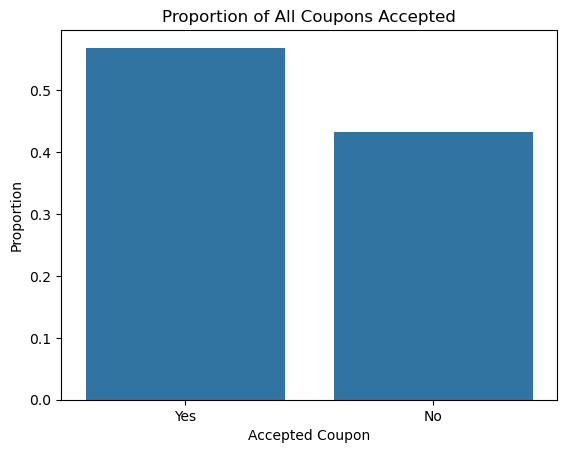

In [29]:
#This barplot shows overall proportion of coupons accepted, which is about 57%,
#versus 43% declined.
counts=data['Y'].value_counts(normalize=True).reset_index()
counts.columns=['Category', 'Proportion']
counts['Category']=counts['Category'].map({0: 'No', 1: 'Yes'})
sns.barplot(data=counts, x='Category', y='Proportion')
plt.xlabel('Accepted Coupon')
plt.ylabel('Proportion')
plt.title('Proportion of All Coupons Accepted')


5. Use a bar plot to visualize the `coupon` column.

In [30]:
#Looking at value counts to get numeric understanding of coupons offered.
coupon_counts=data['coupon'].value_counts()
print(coupon_counts)

coupon
Coffee House             3996
Restaurant(<20)          2786
Carry out & Take away    2393
Bar                      2017
Restaurant(20-50)        1492
Name: count, dtype: int64


The below graph shows a visual breakdown of different coupon types offered. The majority of coupons offered were for Coffee Houses. The least were for restaurants between $20-$50.

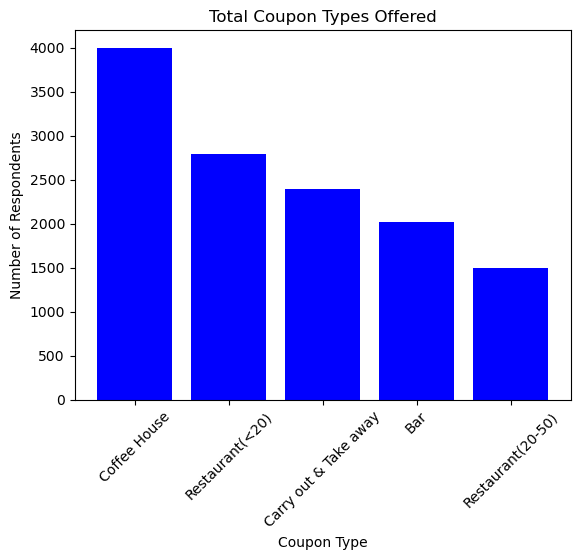

In [31]:
plt.bar(coupon_counts.index, coupon_counts.values, color='blue')
plt.title('Total Coupon Types Offered')
plt.xticks(rotation=45)
plt.xlabel('Coupon Type')
plt.ylabel('Number of Respondents')
plt.show()

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Restaurant(<20)'),
  Text(1, 0, 'Coffee House'),
  Text(2, 0, 'Carry out & Take away'),
  Text(3, 0, 'Bar'),
  Text(4, 0, 'Restaurant(20-50)')])

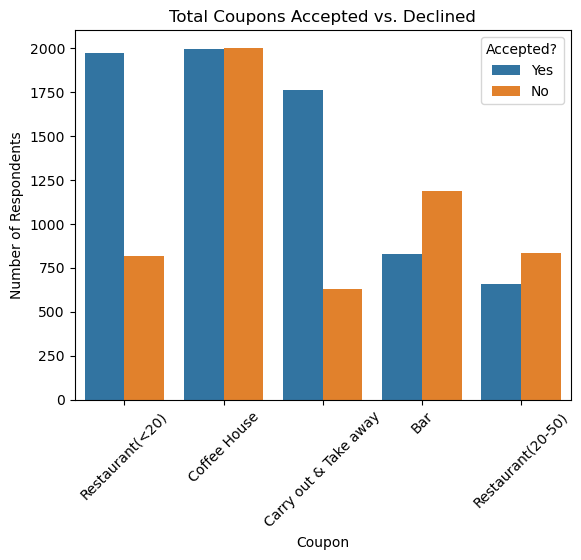

In [32]:
#I am curious to see the acceptance rate of all coupon types.
#The below barplot showcases coupon types accepted compared to declined.
#We can see that Cheap Resaurants were accepted at a higher rate than the rest.
#Carryout and takeaway had a high acceptance rate.
#Coffeehouses, which had the highest offer rate, were accepted about 50% of the time.
data['Accepted?']=data['Y'].map({0:'No', 1:'Yes'})
sns.countplot(data=data, x='coupon', hue='Accepted?')

plt.xlabel('Coupon')
plt.ylabel('Number of Respondents')
plt.title('Total Coupons Accepted vs. Declined')
plt.xticks(rotation=45)

6. Use a histogram to visualize the temperature column.

In [33]:
data['temperature'].value_counts()

temperature
80    6528
55    3840
30    2316
Name: count, dtype: int64

We see that about half of our respondents were enjoying 80 degree weather, whereas about 18% were in 30 degree weather, and about 30% were in 55 degree weather.

Text(0, 0.5, 'Number of Respondents')

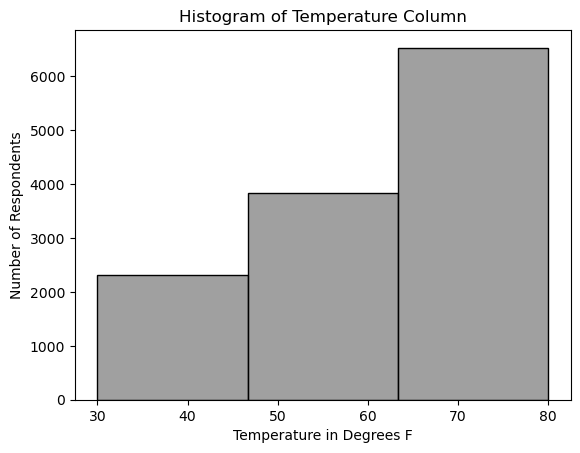

In [176]:
#The below histogram shows the breakdown of temperatures during this experiment.
sns.histplot(data['temperature'], bins=3, color='gray')
plt.title("Histogram of Temperature Column")
plt.xlabel('Temperature in Degrees F')
plt.ylabel('Number of Respondents')

Plotting a histogram to visualize Temperature in comparison to overall coupon acceptance. We can see that about half of respondents in both 30 degree and 55 degree weather accepted a coupon, whereas closer to 65% accepted when temps were 80 degrees. Perhaps the warmer weather made people more inclined to want to stay outdoors and venture.

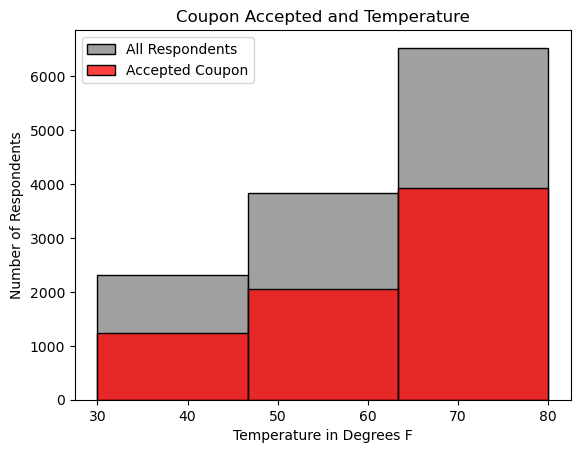

In [177]:
sns.histplot(data['temperature'], bins=3, color='gray', label='All Respondents')

sns.histplot(data[data['Y']==1]['temperature'], bins=3, color='red', label='Accepted Coupon')

plt.title("Coupon Accepted and Temperature")
plt.xlabel('Temperature in Degrees F')
plt.ylabel('Number of Respondents')
plt.legend()
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [36]:
#DataFrame for Bar Coupons that will be used throughout this section.
bar_coupons = data.query('coupon == "Bar"')
type(bar_coupons)

pandas.core.frame.DataFrame

2. What proportion of bar coupons were accepted?

In [37]:
bar_proportion_accepted=bar_coupons['Y'].mean()
print(bar_proportion_accepted)

0.41001487357461575


In [38]:
data.query('coupon == "Bar"')['Y'].value_counts(normalize=True)

Y
0    0.589985
1    0.410015
Name: proportion, dtype: float64

Plotting the proportion of Bar coupons that were accepted versus declined overall. We can see that when it comes to bar coupons, a majority of respondents declined the coupon, at a 59% to 41% ratio.

Text(0.5, 0, 'Coupon Accepted')

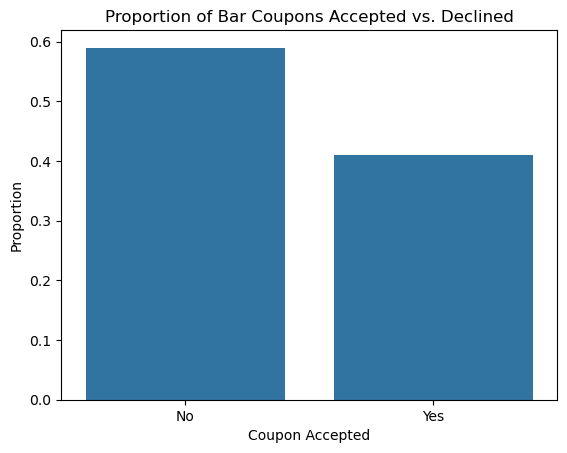

In [39]:
data['Accepted?']=data['Y'].map({0:'No', 1:'Yes'})
bar_coupons=data.query('coupon == "Bar"')
counts=bar_coupons['Accepted?'].value_counts(normalize=True).reset_index()
counts.columns=['Accepted?','Proportion']

sns.barplot(data=counts, x='Accepted?', y='Proportion')
plt.title('Proportion of Bar Coupons Accepted vs. Declined')
plt.xlabel('Coupon Accepted')

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [40]:
#Looking for proportions of respondents that accepted Bar coupons
#based on whether they have frequented a bar over 3 times in the month.
#Creating placeholders and subsets to filter data prior to plotting.
three_or_less=['never', 'less1', '1~3']
over_three_times=['4~8', 'gt8']
bar_three_or_less=bar_coupons[bar_coupons['bar'].isin(three_or_less)]
bar_over_three_times=bar_coupons[bar_coupons['bar'].isin(over_three_times)]
rate_bar_three_or_less=bar_three_or_less['Y'].mean()
rate_bar_over_three_times=bar_over_three_times['Y'].mean()
print("Acceptance 3 or fewer times", rate_bar_three_or_less)
print("Acceptance over 3 times", rate_bar_over_three_times)

Acceptance 3 or fewer times 0.37073707370737075
Acceptance over 3 times 0.7688442211055276


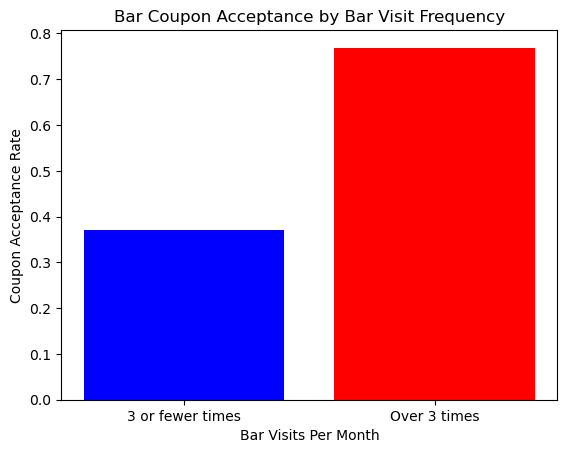

In [41]:
#Plotting a bar graph to showcase the disparity of Bar coupon acceptance
#based on frequent bar visits.
#We can see there is quite an increase in Bar coupon acceptance for respondents who
#enjoy frequenting bars as compared to the overall population of respondents. 
visits = ['3 or fewer times', 'Over 3 times']
acceptance = [rate_bar_three_or_less, rate_bar_over_three_times]


plt.bar(visits, acceptance, color=['blue', 'red'])
plt.xlabel('Bar Visits Per Month')
plt.ylabel('Coupon Acceptance Rate')

plt.title('Bar Coupon Acceptance by Bar Visit Frequency')
plt.show()

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [42]:
#Exploring unique values included in the "age" column to prepare.
data['age'].unique()

array(['21', '46', '26', '31', '41', '50plus', '36', 'below21'],
      dtype=object)

In [43]:
#and checking out how many respondents fall in each age range.
data['age'].value_counts()

age
21         2653
26         2559
31         2039
50plus     1788
36         1319
41         1093
46          686
below21     547
Name: count, dtype: int64

In [179]:
#I have decided to create definitions that separate age ranges in
#groups of over 25 and 25 or below.

def age_group(age):
    if age in ['below21','21']:
        return '25_or_below'
    else:
        return 'over_25'

data['age_group']=data['age'].apply(age_group)
bar_coupons=data.query('coupon == "Bar"')

In [180]:
#and apply in order to find acceptance rates by people
#over 25 and who frequent bars once or more per month.
once_or_more=['1~3', '4~8', 'gt8']
rate_over_25_once_per_month = bar_coupons[
    (bar_coupons['age_group'] == 'over_25') & (bar_coupons['bar'].isin(once_or_more))
]['Y'].mean()
print("Acceptance Rate Over 25 and Over Once Per Month" , rate_over_25_once_per_month)

Acceptance Rate Over 25 and Over Once Per Month 0.6952380952380952


In [81]:
#Then, using ~, finding acceptance rate for all others.
rate_of_all_others= bar_coupons[
    ~((bar_coupons['age_group'] == 'over_25') & (bar_coupons['bar'].isin(once_or_more)))
]['Y'].mean()
print("Acceptance Rate of All Others", rate_of_all_others)

Acceptance Rate of All Others 0.33500313087038197


Text(0.5, 1.0, 'Bar Coupon Acceptance Based on Age and More than 1 Bar Visit per Month')

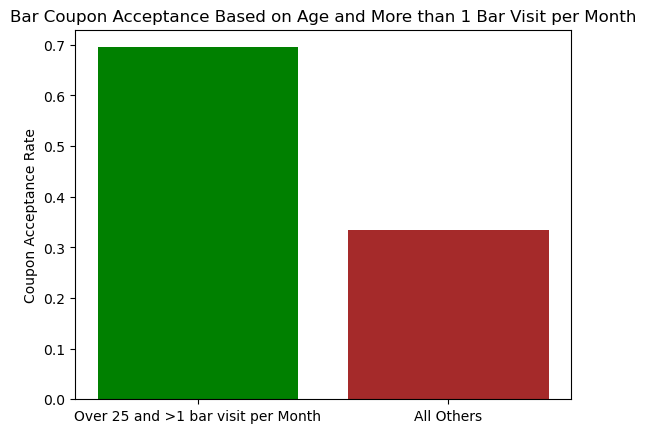

In [181]:
#Creating bar plot showcasing that the acceptance rate of Bar coupons
#is significantly greater for respondents that are over 25 and visit a bar
#more than once per month, as compared to all others.
groups = ['Over 25 and >1 bar visit per Month', 'All Others']
acceptance = [rate_over_25_once_per_month, rate_of_all_others]

plt.bar(groups, acceptance, color=['green', 'brown'])
plt.ylabel('Coupon Acceptance Rate')

plt.title('Bar Coupon Acceptance Based on Age and More than 1 Bar Visit per Month')


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [48]:
#Exploring unique entries in the passenger and occupation columns
#to help prepare for filtering.
data['passenger'].unique()

array(['Alone', 'Friend(s)', 'Kid(s)', 'Partner'], dtype=object)

In [49]:
data['occupation'].unique()

array(['Unemployed', 'Architecture & Engineering', 'Student',
       'Education&Training&Library', 'Healthcare Support',
       'Healthcare Practitioners & Technical', 'Sales & Related',
       'Management', 'Arts Design Entertainment Sports & Media',
       'Computer & Mathematical', 'Life Physical Social Science',
       'Personal Care & Service', 'Community & Social Services',
       'Office & Administrative Support', 'Construction & Extraction',
       'Legal', 'Retired', 'Installation Maintenance & Repair',
       'Transportation & Material Moving', 'Business & Financial',
       'Protective Service', 'Food Preparation & Serving Related',
       'Production Occupations',
       'Building & Grounds Cleaning & Maintenance',
       'Farming Fishing & Forestry'], dtype=object)

In [183]:
#Creating lists of excluded occupations as well as to filter by drivers
#that had a passenger that was not a kid. Therefore I am excluding 'Alone' as well.
excluded_jobs = ['farming', 'fishing', 'forestry']

excluded_passenger = ['Kid(s)','Alone']


In [184]:
#list for frequency of one or more visits
once_or_more=['1~3', '4~8', 'gt8']

In [185]:
#This group, which consists of bar coupon recipients that frequent a bar more than once
#per month, who do not have an occupation including farming, fishing, or forestry. 
#And who had a passenger that was not a kid.
#Calculating the acceptance rate of Bar coupons for respondents meeting this criteria.
this_group = bar_coupons[
    (bar_coupons['bar'].isin(once_or_more))&
    (~bar_coupons['occupation'].isin(excluded_jobs))&
    (~bar_coupons['passenger'].isin(excluded_passenger))
    ]

acceptance_rate = this_group['Y'].mean()
print(acceptance_rate)


0.717948717948718


In [84]:
#and using ~ getting the acceptance rate of bar coupons for all others.
all_others = bar_coupons[
   ~(
       (bar_coupons['bar'].isin(once_or_more))&
    (~bar_coupons['occupation'].isin(excluded_jobs))&
    (~bar_coupons['passenger'].isin(excluded_passenger))
   )
    ]
acceptance_rate_all_others = all_others['Y'].mean()
print(acceptance_rate_all_others)

0.3770581778265642


Text(0.5, 1.0, 'Bar Visits >1 per Month, With non-Kid Passenger, No Farming, Fishing, or Forestry Occupation')

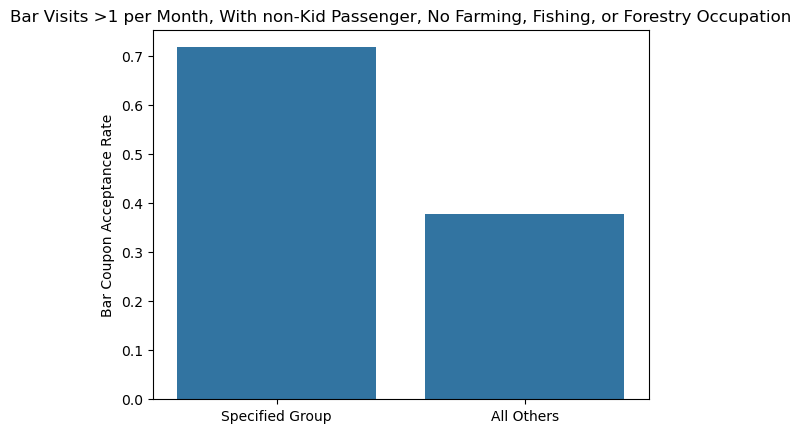

In [85]:
#On this bar graph, we can see that respondents who frequent bars more than once per month,
#who do not work in farming, fishing, or forestry, and who were traveling with a passenger
#that was not a kid, accepted Bar coupons at a much higher rate, about 72% to 38%.
acceptance_rate = this_group['Y'].mean()
acceptance_rate_all_others = all_others['Y'].mean()
data.plot = pd.DataFrame({
    'Group':['Specified Group','All Others'],
    'Acceptance Rate': [acceptance_rate, acceptance_rate_all_others]
})
sns.barplot(data=data.plot, x='Group', y='Acceptance Rate')
plt.xlabel('')
plt.ylabel('Bar Coupon Acceptance Rate')
plt.title('Bar Visits >1 per Month, With non-Kid Passenger, No Farming, Fishing, or Forestry Occupation')

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [55]:
#Exploring unique entries for Marital Status to prepare.
data['marital_status'].unique()

array(['Unmarried partner', 'Single', 'Married partner', 'Divorced',
       'Widowed'], dtype=object)

In [86]:
#creating a group consisting of drivers who frequent a bar more than once per month,
#had passengers that were not kids, and were not widowed.
#Getting this Bar coupon acceptance rate.
exclude_widowed = ['Widowed']
group_a = bar_coupons[
    (bar_coupons['bar'].isin(once_or_more))&
    (~bar_coupons['marital_status'].isin(exclude_widowed))&
    (~bar_coupons['passenger'].isin(excluded_passenger))
    ]

acceptance_rate_a = group_a['Y'].mean()
print(acceptance_rate_a)


0.717948717948718


In [57]:
#Unique entries for Age column for filtering purposes.
data['age'].unique()

array(['21', '46', '26', '31', '41', '50plus', '36', 'below21'],
      dtype=object)

In [58]:
#identifying group for those under 30
age_under_30=['21','26','below21']

In [87]:
#Creating group consisting of respondents under 30 that frequent bars more than once per month.
group_b = bar_coupons[
    (bar_coupons['bar'].isin(once_or_more))&
    (bar_coupons['age'].isin(age_under_30))]

acceptance_rate_b = group_b['Y'].mean()
print(acceptance_rate_b)

0.7217391304347827


In [60]:
#Exploring unique entries for cheap restaurants.
data['restaurant_less_than_20'].unique()

array(['4~8', '1~3', 'less1', 'gt8', 'never'], dtype=object)

In [61]:
#Exploring unique entries for income column.
data['income'].unique()

array(['$37500 - $49999', '$62500 - $74999', '$12500 - $24999',
       '$75000 - $87499', '$50000 - $62499', '$25000 - $37499',
       '$100000 or More', '$87500 - $99999', 'Less than $12500'],
      dtype=object)

In [62]:
#creating list of 4 or more to use:
four_or_more=['4~8','gt8']

In [63]:
#and creating list for income less than $50k.
income_less_than_50k=['$37500 - $49999','$12500 - $24999','$25000 - $37499','Less than $12500']

In [88]:
#Creating a third group, "group-c", consisting of bar coupon recipients that
#make less than $50k and frequent cheap restaurants 4 or more times per month.
group_c = bar_coupons [
    (bar_coupons['restaurant_less_than_20'].isin(four_or_more)) &
    (bar_coupons['income'].isin(income_less_than_50k))]
acceptance_rate_c = group_c['Y'].mean()
print(acceptance_rate_c)

0.45348837209302323


([0, 1, 2],
 [Text(0, 0, 'Bar >1/mo., Not widowed, no kid pass., '),
  Text(1, 0, 'Under 30, Bar >1/mo'),
  Text(2, 0, 'Income <$50k, cheap restaurant 4/mo.')])

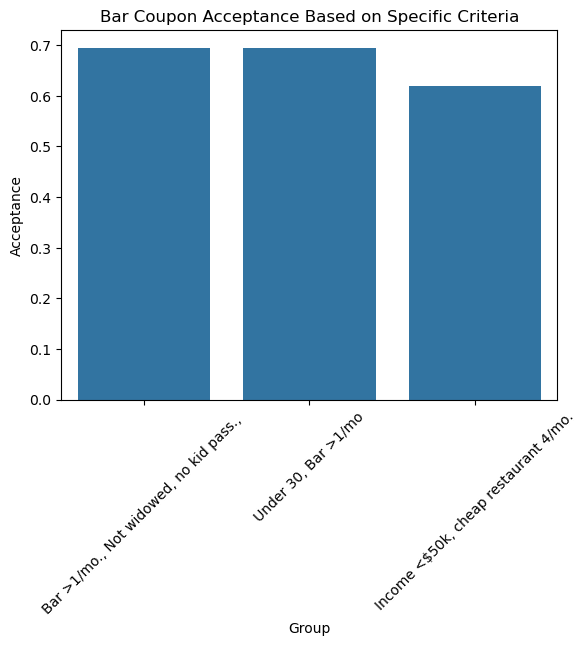

In [192]:
#Plotting a Bar plot to visualize the 3 different groups.
#There is a significant drop in terms of Bar coupon acceptance for people that
#make less than $50k, and who frequent cheap restaurants. The drop is from about 70% for 
#the first 2 groups, to about 45% for this group.
data.plot=pd.DataFrame({
    'Group':['Bar >1/mo., Not widowed, no kid pass., ', 'Under 30, Bar >1/mo', 'Income <$50k, cheap restaurant 4/mo.'],
    'Acceptance' :[acceptance_rate_a, acceptance_rate_b, acceptance_rate_c]
})

sns.barplot(data=data.plot, x='Group', y='Acceptance')
plt.title('Bar Coupon Acceptance Based on Specific Criteria')
plt.xticks(rotation=45)

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

Based on my observations, it appears that bar coupons in general, were not as popular as coupons for restaurants under 20 dollars, and for carryout and takeaway food. In fact, out of all coupon categories, bar coupons had the highest proportion of people decline them. Perhaps this is due to what we find in the data during analysis. It is evident that the people who chose to accept bar coupons, they typically frequent bars regualrly at a higher rate. This might be indicative of the greater population of respondents during this study, as it is possible that the majority of people do not regualrly frequent bars. Other criteria that seemed to be deciding factors, include whether the driver had a kid as a passenger, and whether the driver regularly frequents cheap restaurants. We see a stark decline in respondents that declined bar coupons from the group that likes cheap restaurants and makes less than 50k. Perhaps their money is better spent on sustenance rather than cocktails.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In my independent investigation, I chose to look into respondents that accpeted coupons for Restaurants under $20. This is the category with the highest acceptance rate, at about 70%. I wanted to explore what factors contributed to people accepting versus declining these coupons. While my findings did not showcase as many disparities as Bar coupons, there were a few things that stood out.

In [107]:
#Exploring a bit of the data.
cheap_restaurant = data.query('coupon == "Restaurant(<20)"')
print(cheap_restaurant.shape[0])

2786


Text(0.5, 0, 'Coupon Accepted')

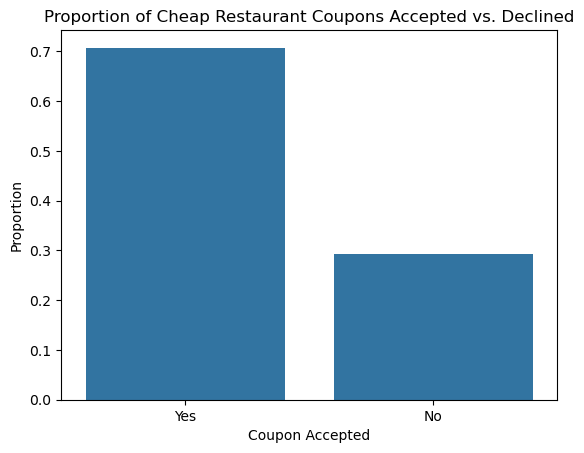

In [112]:
#Plotting a bar graph to showcase a visual of the proportion of respondents
#that accepted. We see it's about 70%.
data['Accepted?']=data['Y'].map({0:'No', 1:'Yes'})
cheap_restaurant=data.query('coupon == "Restaurant(<20)"')
counts=cheap_restaurant['Accepted?'].value_counts(normalize=True).reset_index()
counts.columns=['Accepted?','Proportion']

sns.barplot(data=counts, x='Accepted?', y='Proportion')
plt.title('Proportion of Cheap Restaurant Coupons Accepted vs. Declined')
plt.xlabel('Coupon Accepted')

In [110]:
#I wanted to see if time of day was a factor.
#Checking out unique 'time' entries to prepare for filtering.
data['time'].unique()

array(['2PM', '10AM', '6PM', '7AM', '10PM'], dtype=object)

In [113]:
#I assumed that evening times could be significant, so I separated those out.
evening_times=['6PM','10PM']

In [118]:
#I made a group filtered by recipients that accepted cheap restaurant coupons in the evening,
#and whose income is less than $50k. This group accepted at a rate of just shy of 70%,
#which is pretty much in line with the overall population. I assumed that this would be higher,
#thinking that perhaps fast food coupons, in the evening, would be more greatly accepted by
#people with lower incomes. 
group_a=cheap_restaurant[
    (cheap_restaurant['time'].isin(evening_times))&
    (cheap_restaurant['income'].isin(income_less_than_50k))
]
acceptance_rate_a = group_a['Y'].mean()
print(acceptance_rate_a)

0.6953846153846154


In [186]:
#I created another group consisting of all others (those that are not in the evening,
#and who do not make less than $50k. The acceptance rate hardly changed.
group_b=cheap_restaurant[
    (~cheap_restaurant['time'].isin(evening_times))&
    (~cheap_restaurant['income'].isin(income_less_than_50k))
    ]
acceptance_rate_b = group_b['Y'].mean()
print(acceptance_rate_b)

0.6942590120160214


In [123]:
cheap_restaurant['marital_status'].unique()

array(['Unmarried partner', 'Single', 'Married partner', 'Divorced',
       'Widowed'], dtype=object)

In [127]:
with_partner=['Unmarried partner', 'Married partner']

In [143]:
#I questioned whether marital status played a role, and it did not.
subset = cheap_restaurant[cheap_restaurant['marital_status'].isin(['Unmarried partner', 'Married partner'])]
acceptance_rate = subset['Y'].mean()
print(acceptance_rate)

0.7005649717514124


In [144]:
cheap_restaurant['expiration'].unique()

array(['1d', '2h'], dtype=object)

In [153]:
#I then wanted to see if people were less inclined to accept a cheap restaurant coupon
#in the evening, who made less than $50k, when the coupon was about to expire in 2 hours.
#The 2 hour coupon expiration seemed to have an impact. We can see the acceptance rate 
#drops off by about 9%.
group_c=cheap_restaurant[
    (cheap_restaurant['time'].isin(evening_times))&
    (cheap_restaurant['income'].isin(income_less_than_50k))&
    (cheap_restaurant['expiration'] == '2h')
]
acceptance_rate_c = group_c['Y'].mean()
print(acceptance_rate_c)

0.6198547215496368


In [187]:
#I then wanted to see how age played into this. What I found was another significant 
#drop in acceptance from respondents over 46 years old. In this group I continiued to look at 
#coupons that expired in 2 hours, but with respondents that are older, and are not in the 
#less than $50k income bracket. These folks accepted cheap restaurant coupons at our lowest
#rate here, at 52%.
group_d=cheap_restaurant[
    (cheap_restaurant['age'].isin (['46', '50plus']))&
    (~cheap_restaurant['income'].isin(income_less_than_50k))&
    (cheap_restaurant['expiration'] == '2h')
]
acceptance_rate_d = group_d['Y'].mean()
print(acceptance_rate_d)

0.5178571428571429


([0, 1, 2, 3],
 [Text(0, 0, 'Evening, Income less than $50k'),
  Text(1, 0, 'Not Evening, Income not less than $50k'),
  Text(2, 0, 'Evening, Income less than $50k, Expires in 2hr'),
  Text(3, 0, 'Age Over 46, Expires in 2hrs, Income less than $50k')])

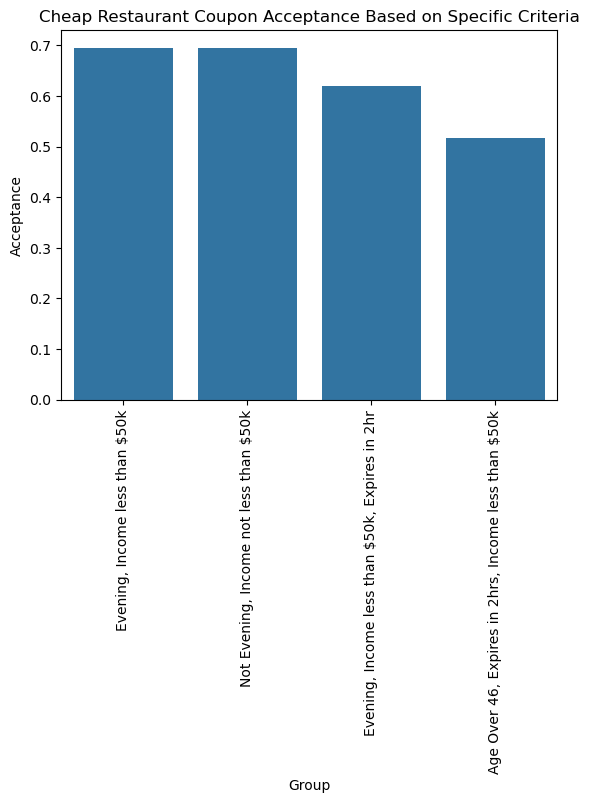

In [173]:
#I plotted a bar graph of these findings, showcasing the above mentioned
#4 groups. We can clearly see that once the 2 hour expiration is introduced, on the 
#most popular coupon offered, this negatively impacts the acceptance rate. I believe that 
#people are less inclined to accept a coupon that is about to expire because they don't
#want to interrupt their current plans, or feel pressured to change what they are doing.
#In addition, I believe this is more prominent for older folks who have higher incomes,
#because they have different perceptions of time and value. Plus, they might have already
#eaten a nice meal.
data.plot=pd.DataFrame({
    'Group':['Evening, Income less than $50k', 'Not Evening, Income not less than $50k', 'Evening, Income less than $50k, Expires in 2hr','Age Over 46, Expires in 2hrs, Income less than $50k'],
    'Acceptance' :[acceptance_rate_a, acceptance_rate_b, acceptance_rate_c, acceptance_rate_d]
})

sns.barplot(data=data.plot, x='Group', y='Acceptance')
plt.title('Cheap Restaurant Coupon Acceptance Based on Specific Criteria')
plt.xticks(rotation=90)